In [1]:
import numpy as np
import os

# ✅ 改成你解壓後的檔案位置
npy_path = r"C:\Users\User\Documents\465 HW\project\AAAAAA\STO_final_aligned.npy"

assert os.path.exists(npy_path), f"找不到檔案：{npy_path}"

D = np.load(npy_path, mmap_mode="r")  # memmap：不會整包載入 RAM
print("Loaded:", npy_path)
print("shape:", D.shape, "dtype:", D.dtype)

Ny, Nx, Ky, Kx = D.shape
print("Scan grid (Ny,Nx) =", (Ny, Nx), " | DP size (Ky,Kx) =", (Ky, Kx))

Loaded: C:\Users\User\Documents\465 HW\project\AAAAAA\STO_final_aligned.npy
shape: (256, 256, 128, 128) dtype: float32
Scan grid (Ny,Nx) = (256, 256)  | DP size (Ky,Kx) = (128, 128)


avg_dp computed from 65536 patterns


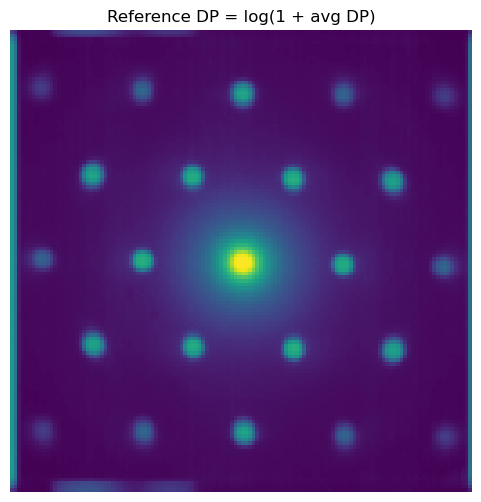

In [4]:
import matplotlib.pyplot as plt
avg_dp = np.zeros((Ky, Kx), dtype=np.float64)
block = 16
count = 0

for y0 in range(0, Ny, block):
    for x0 in range(0, Nx, block):
        y1 = min(Ny, y0 + block)
        x1 = min(Nx, x0 + block)
        chunk = np.asarray(D[y0:y1, x0:x1, :, :], dtype=np.float64)
        avg_dp += chunk.sum(axis=(0, 1))
        count += (y1 - y0) * (x1 - x0)

avg_dp /= count
print("avg_dp computed from", count, "patterns")

plt.figure(figsize=(6, 6))
plt.imshow(np.log1p(avg_dp), origin="upper")  # ✅ (0,0) 左上
plt.title("Reference DP = log(1 + avg DP)")
plt.axis("off")
plt.show()

Num candidates: 11
Top candidates (y,x): [array([88, 78], dtype=int64), array([63, 36], dtype=int64), array([41, 78], dtype=int64), array([40, 50], dtype=int64), array([87, 50], dtype=int64), array([65, 92], dtype=int64), array([17, 64], dtype=int64), array([111,  64], dtype=int64), array([40, 22], dtype=int64), array([ 88, 106], dtype=int64)]
Selected p1: [88 78] vector: (24, 14)
Selected p2: [63 36] vector: (-1, -28)
Angle(deg): 122.30184565241646


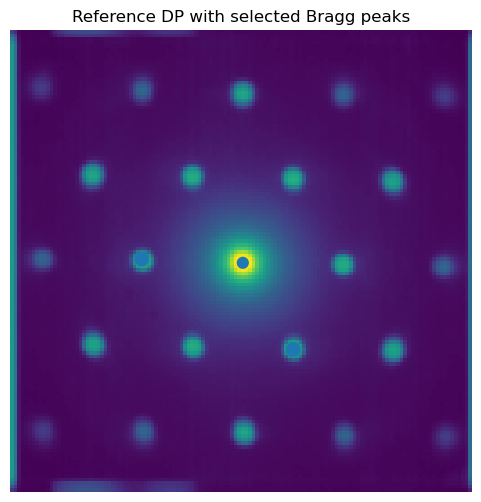

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, maximum_filter
cy, cx = avg_dp.shape[0]//2, avg_dp.shape[1]//2
avg_s = gaussian_filter(avg_dp.astype(np.float64), sigma=1.0)

# mask out center beam
rr = 8
Y, X = np.ogrid[:Ky, :Kx]
center_mask = (Y - cy) ** 2 + (X - cx) ** 2 <= rr ** 2
avg_s2 = avg_s.copy()
avg_s2[center_mask] = 0.0

# local maxima candidates
neigh = 5
mx = maximum_filter(avg_s2, size=neigh)
cand = np.argwhere((avg_s2 == mx) & (avg_s2 > np.percentile(avg_s2, 99.7)))
cand = sorted(cand, key=lambda p: avg_s2[p[0], p[1]], reverse=True)
print("Num candidates:", len(cand))
print("Top candidates (y,x):", cand[:10])

def angle_between(v1, v2):
    v1 = np.array(v1, float); v2 = np.array(v2, float)
    num = np.dot(v1, v2)
    den = np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-12
    c = np.clip(num/den, -1, 1)
    return np.degrees(np.arccos(c))

min_r = 12
min_angle = 20

p1 = None
p2 = None

for p in cand:
    v = np.array([p[0]-cy, p[1]-cx], float)
    if np.linalg.norm(v) >= min_r:
        p1 = np.array(p)
        break

for p in cand:
    v1 = np.array([p1[0]-cy, p1[1]-cx], float)
    v2 = np.array([p[0]-cy,  p[1]-cx], float)
    if np.linalg.norm(v2) < min_r:
        continue
    ang = angle_between(v1, v2)
    if ang >= min_angle and ang <= (180-min_angle):
        p2 = np.array(p)
        break

print("Selected p1:", p1, "vector:", (p1[0]-cy, p1[1]-cx))
print("Selected p2:", p2, "vector:", (p2[0]-cy, p2[1]-cx))
print("Angle(deg):", angle_between([p1[0]-cy, p1[1]-cx], [p2[0]-cy, p2[1]-cx]))

plt.figure(figsize=(6, 6))
plt.imshow(np.log1p(avg_dp), origin="upper")  # ✅ (0,0) 左上
plt.scatter([cx, p1[1], p2[1]], [cy, p1[0], p2[0]], s=[60, 90, 90])
plt.title("Reference DP with selected Bragg peaks")
plt.axis("off")
plt.show()

In [7]:
from scipy.ndimage import gaussian_filter

# ---- tunables (start with these) ----
halfwin = 14
sigma_dp = 0.8
search_half = 4
snr_min = 1.5
jump_max = 18
bg_mode = 'median'
# -----------------------------------

def peak_max_then_centroid(dp, yx0, halfwin=8, search_half=3, bg_mode="median"):
    y0, x0 = int(yx0[0]), int(yx0[1])
    y1, y2 = max(0, y0-halfwin), min(dp.shape[0], y0+halfwin+1)
    x1, x2 = max(0, x0-halfwin), min(dp.shape[1], x0+halfwin+1)

    win = dp[y1:y2, x1:x2].astype(np.float64)
    bg = np.median(win) if bg_mode == "median" else np.mean(win)

    win2 = win - bg
    win2[win2 < 0] = 0.0
    if win2.sum() <= 1e-12:
        return np.nan, np.nan, np.nan, bg, np.nan

    # integer max
    iy, ix = np.unravel_index(np.argmax(win2), win2.shape)
    ypk = y1 + iy
    xpk = x1 + ix
    peak_val = win[iy, ix]

    # centroid around max
    ys1, ys2 = max(0, ypk-search_half), min(dp.shape[0], ypk+search_half+1)
    xs1, xs2 = max(0, xpk-search_half), min(dp.shape[1], xpk+search_half+1)

    sub = dp[ys1:ys2, xs1:xs2].astype(np.float64)
    bg2 = np.median(sub) if bg_mode == "median" else np.mean(sub)

    sub2 = sub - bg2
    sub2[sub2 < 0] = 0.0
    s = sub2.sum()
    if s <= 1e-12:
        return np.nan, np.nan, peak_val, bg2, np.nan

    yy, xx = np.mgrid[ys1:ys2, xs1:xs2]
    yc = (yy * sub2).sum() / s
    xc = (xx * sub2).sum() / s

    # simple SNR-like metric
    snr = (peak_val - bg2) / (np.std(sub) + 1e-12)
    return yc, xc, peak_val, bg2, snr


g1x = np.full((Ny, Nx), np.nan)
g1y = np.full((Ny, Nx), np.nan)
g2x = np.full((Ny, Nx), np.nan)
g2y = np.full((Ny, Nx), np.nan)

v1_ref = np.array([p1[0]-cy, p1[1]-cx], dtype=float)
v2_ref = np.array([p2[0]-cy, p2[1]-cx], dtype=float)

print("Tracking peaks...")
for iy in range(Ny):
    for ix in range(Nx):
        dp = np.asarray(D[iy, ix], dtype=np.float32)
        if sigma_dp > 0:
            dp = gaussian_filter(dp, sigma=sigma_dp)

        y1, x1, pk1, bg1, snr1 = peak_max_then_centroid(dp, p1, halfwin=halfwin, search_half=search_half, bg_mode=bg_mode)
        y2, x2, pk2, bg2, snr2 = peak_max_then_centroid(dp, p2, halfwin=halfwin, search_half=search_half, bg_mode=bg_mode)

        if not (np.isfinite(y1) and np.isfinite(x1) and np.isfinite(y2) and np.isfinite(x2)):
            continue
        if (snr1 < snr_min) or (snr2 < snr_min):
            continue

        v1 = np.array([y1-cy, x1-cx], float)
        v2 = np.array([y2-cy, x2-cx], float)

        if (np.linalg.norm(v1 - v1_ref) > jump_max) or (np.linalg.norm(v2 - v2_ref) > jump_max):
            continue

        g1y[iy, ix], g1x[iy, ix] = v1[0], v1[1]
        g2y[iy, ix], g2x[iy, ix] = v2[0], v2[1]

    if (iy+1) % 32 == 0:
        print(f"  done {iy+1}/{Ny}")

valid = np.isfinite(g1x) & np.isfinite(g1y) & np.isfinite(g2x) & np.isfinite(g2y)
print("Valid tracked:", np.count_nonzero(valid), "/", Ny*Nx)

Tracking peaks...
  done 32/256
  done 64/256
  done 96/256
  done 128/256
  done 160/256
  done 192/256
  done 224/256
  done 256/256
Valid tracked: 63938 / 65536


In [8]:
g1_ref_med = np.array([np.nanmedian(g1x[valid]), np.nanmedian(g1y[valid])], dtype=float)
g2_ref_med = np.array([np.nanmedian(g2x[valid]), np.nanmedian(g2y[valid])], dtype=float)
B0 = np.column_stack([g1_ref_med, g2_ref_med])
Binv0 = np.linalg.inv(B0)

exx   = np.full((Ny, Nx), np.nan)
eyy   = np.full((Ny, Nx), np.nan)
exy   = np.full((Ny, Nx), np.nan)
theta = np.full((Ny, Nx), np.nan)

I2 = np.eye(2)

for iy in range(Ny):
    for ix in range(Nx):
        if not valid[iy, ix]:
            continue
        B = np.array([[g1x[iy, ix], g2x[iy, ix]],
                      [g1y[iy, ix], g2y[iy, ix]]], dtype=float)

        A = B @ Binv0         # A = F^{-T}
        F = np.linalg.inv(A.T)

        H = F - I2
        eps = 0.5*(H + H.T)
        omg = 0.5*(H - H.T)

        exx[iy, ix]   = eps[0, 0]
        eyy[iy, ix]   = eps[1, 1]
        exy[iy, ix]   = eps[0, 1]
        theta[iy, ix] = omg[1, 0]   # radians

In [9]:
def nan_gauss(a, sigma=1.0):
    m = np.isfinite(a).astype(float)
    a0 = np.nan_to_num(a, nan=0.0)
    num = gaussian_filter(a0, sigma=sigma, mode="nearest")
    den = gaussian_filter(m,  sigma=sigma, mode="nearest")
    out = num / np.maximum(den, 1e-12)
    out[den < 1e-6] = np.nan
    return out

smooth_sigma_map = 1.0
exx_s   = nan_gauss(exx,   sigma=smooth_sigma_map)
eyy_s   = nan_gauss(eyy,   sigma=smooth_sigma_map)
exy_s   = nan_gauss(exy,   sigma=smooth_sigma_map)
theta_s = nan_gauss(theta, sigma=smooth_sigma_map)

def pr(x, name):
    v = x[np.isfinite(x)]
    print(f"{name:6s} median {np.median(v): .6g} | p95(|.|) {np.percentile(np.abs(v),95): .6g} | p99(|.|) {np.percentile(np.abs(v),99): .6g}")

print("\nStats (after smoothing):")
pr(exx_s, "exx")
pr(eyy_s, "eyy")
pr(exy_s, "exy")
pr(theta_s*180/np.pi, "theta")


Stats (after smoothing):
exx    median  0.00145293 | p95(|.|)  0.294874 | p99(|.|)  0.691672
eyy    median  0.00158178 | p95(|.|)  0.517189 | p99(|.|)  1.34048
exy    median -0.000130316 | p95(|.|)  0.155342 | p99(|.|)  0.681325
theta  median  0.116528 | p95(|.|)  7.74224 | p99(|.|)  18.7835


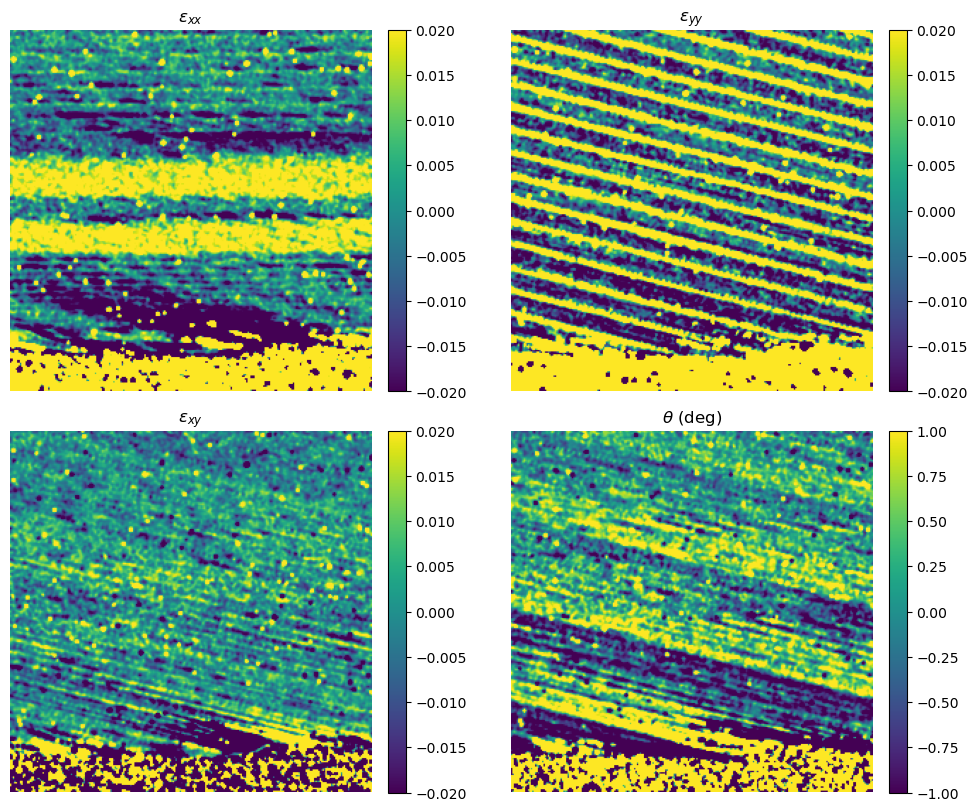

In [10]:
strain_lim = 0.02
theta_lim_deg = 1.0

fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

im = axs[0, 0].imshow(exx_s, origin="upper")
axs[0, 0].set_title(r"$\epsilon_{xx}$")
axs[0, 0].axis("off")
im.set_clim(-strain_lim, strain_lim)
plt.colorbar(im, ax=axs[0, 0], fraction=0.046, pad=0.04)

im = axs[0, 1].imshow(eyy_s, origin="upper")
axs[0, 1].set_title(r"$\epsilon_{yy}$")
axs[0, 1].axis("off")
im.set_clim(-strain_lim, strain_lim)
plt.colorbar(im, ax=axs[0, 1], fraction=0.046, pad=0.04)

im = axs[1, 0].imshow(exy_s, origin="upper")
axs[1, 0].set_title(r"$\epsilon_{xy}$")
axs[1, 0].axis("off")
im.set_clim(-strain_lim, strain_lim)
plt.colorbar(im, ax=axs[1, 0], fraction=0.046, pad=0.04)

im = axs[1, 1].imshow(theta_s * 180 / np.pi, origin="upper")
axs[1, 1].set_title(r"$\theta$ (deg)")
axs[1, 1].axis("off")
im.set_clim(-theta_lim_deg, theta_lim_deg)
plt.colorbar(im, ax=axs[1, 1], fraction=0.046, pad=0.04)

plt.show()


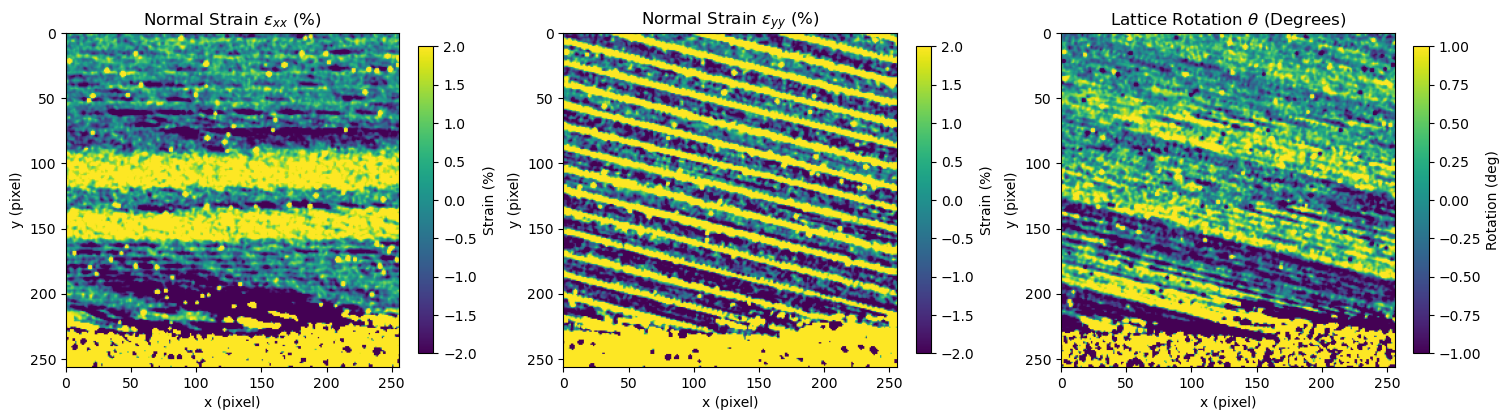

In [16]:
strain_lim = 0.02
theta_lim_deg = 1.0

fig, axs = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

xticks = [0, 50, 100, 150, 200, 250]
yticks = [0, 50, 100, 150, 200, 250]

# exx
im = axs[0].imshow(exx_s * 100, origin="upper", extent=[0, 256, 256, 0])
axs[0].set_title(r"Normal Strain $\epsilon_{xx}$ (%)")
axs[0].set_xlabel("x (pixel)")
axs[0].set_ylabel("y (pixel)")
axs[0].set_xticks(xticks)
axs[0].set_yticks(yticks)
im.set_clim(-strain_lim * 100, strain_lim * 100)
cbar = plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_label("Strain (%)")

# eyy
im = axs[1].imshow(eyy_s * 100, origin="upper", extent=[0, 256, 256, 0])
axs[1].set_title(r"Normal Strain $\epsilon_{yy}$ (%)")
axs[1].set_xlabel("x (pixel)")
axs[1].set_ylabel("y (pixel)")
axs[1].set_xticks(xticks)
axs[1].set_yticks(yticks)
im.set_clim(-strain_lim * 100, strain_lim * 100)
cbar = plt.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
cbar.set_label("Strain (%)")

# theta
im = axs[2].imshow(theta_s * 180 / np.pi, origin="upper", extent=[0, 256, 256, 0])
axs[2].set_title(r"Lattice Rotation $\theta$ (Degrees)")
axs[2].set_xlabel("x (pixel)")
axs[2].set_ylabel("y (pixel)")
axs[2].set_xticks(xticks)
axs[2].set_yticks(yticks)
im.set_clim(-theta_lim_deg, theta_lim_deg)
cbar = plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)
cbar.set_label("Rotation (deg)")

# 存圖
plt.savefig("strain_rotation_maps.png", dpi=300, bbox_inches="tight")

plt.show()

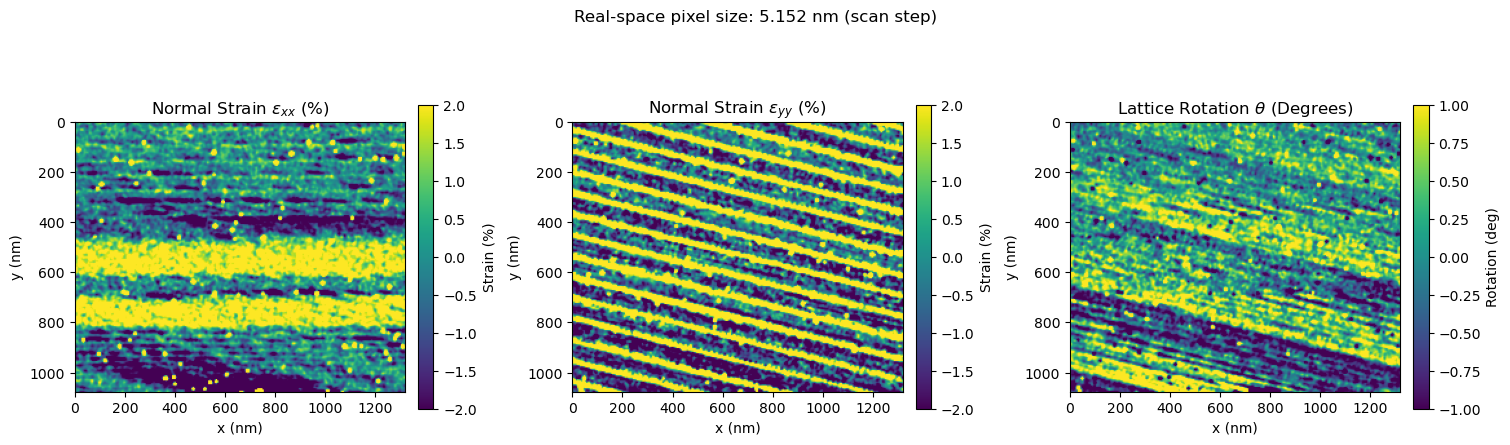

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# real-space calibration
# -------------------------
real_space_step = 5.152   # nm per pixel
y_cut_nm = 1081.0         # crop away vacuum below this y

# 將 nm 轉成 pixel index
ny, nx = exx_s.shape
y_cut_px = int(np.floor(y_cut_nm / real_space_step))

# 避免超出範圍
y_cut_px = min(y_cut_px, ny)

# -------------------------
# crop data (只保留上方有數據區)
# -------------------------
exx_crop = exx_s[:y_cut_px, :]
eyy_crop = eyy_s[:y_cut_px, :]
theta_crop = theta_s[:y_cut_px, :]

# -------------------------
# display limits
# -------------------------
strain_lim = 0.02
theta_lim_deg = 1.0

# 真實座標範圍（單位 nm）
x_max_nm = nx * real_space_step
y_max_nm = y_cut_px * real_space_step

# 比較漂亮的刻度
xticks_nm = np.arange(0, x_max_nm + 1, 200)
yticks_nm = np.arange(0, y_max_nm + 1, 200)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

# -------------------------
# exx
# -------------------------
im = axs[0].imshow(
    exx_crop * 100,
    origin="upper",
    extent=[0, x_max_nm, y_max_nm, 0]
)
axs[0].set_title(r"Normal Strain $\epsilon_{xx}$ (%)")
axs[0].set_xlabel("x (nm)")
axs[0].set_ylabel("y (nm)")
axs[0].set_xticks(xticks_nm)
axs[0].set_yticks(yticks_nm)
im.set_clim(-strain_lim * 100, strain_lim * 100)
cbar = plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
cbar.set_label("Strain (%)")

# -------------------------
# eyy
# -------------------------
im = axs[1].imshow(
    eyy_crop * 100,
    origin="upper",
    extent=[0, x_max_nm, y_max_nm, 0]
)
axs[1].set_title(r"Normal Strain $\epsilon_{yy}$ (%)")
axs[1].set_xlabel("x (nm)")
axs[1].set_ylabel("y (nm)")
axs[1].set_xticks(xticks_nm)
axs[1].set_yticks(yticks_nm)
im.set_clim(-strain_lim * 100, strain_lim * 100)
cbar = plt.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)
cbar.set_label("Strain (%)")

# -------------------------
# theta
# -------------------------
im = axs[2].imshow(
    theta_crop * 180 / np.pi,
    origin="upper",
    extent=[0, x_max_nm, y_max_nm, 0]
)
axs[2].set_title(r"Lattice Rotation $\theta$ (Degrees)")
axs[2].set_xlabel("x (nm)")
axs[2].set_ylabel("y (nm)")
axs[2].set_xticks(xticks_nm)
axs[2].set_yticks(yticks_nm)
im.set_clim(-theta_lim_deg, theta_lim_deg)
cbar = plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04)
cbar.set_label("Rotation (deg)")

# 可選：在整張圖上方加註 scan step
fig.suptitle("Real-space pixel size: 5.152 nm (scan step)", fontsize=12)

# 存圖
plt.savefig("strain_rotation_maps_realspace_cropped.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
import numpy as np

def pr(x, name):
    v = x[np.isfinite(x)]
    print(name, "median", np.median(v), "p95(|.|)", np.percentile(np.abs(v),95), "p99(|.|)", np.percentile(np.abs(v),99))

pr(exx_s, "exx")
pr(eyy_s, "eyy")
pr(exy_s, "exy")
pr(theta_s*180/np.pi, "theta(deg)")

exx median 0.0014529255201254825 p95(|.|) 0.29487418637771773 p99(|.|) 0.6916723156142612
eyy median 0.0015817830476795424 p95(|.|) 0.5171887744263459 p99(|.|) 1.3404787382530492
exy median -0.0001303163109238154 p95(|.|) 0.15534220343376395 p99(|.|) 0.6813251541654262
theta(deg) median 0.11652798796407672 p95(|.|) 7.742244382794478 p99(|.|) 18.783548441398242
